# 1. Setup & Environment
Installing all required libraries.

In [1]:
!pip install xgboost shap imbalanced-learn pandas numpy matplotlib scikit-learn optuna --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import optuna
import xgboost as xgb

from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.impute import SimpleImputer
from sklearn.metrics import (roc_auc_score, roc_curve, brier_score_loss,
                              precision_recall_curve, confusion_matrix)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils import resample
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
plt.style.use("seaborn-v0_8")
print("All libraries imported successfully.")

Matplotlib is building the font cache; this may take a moment.
c:\Users\maith\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully.


# 2. Data Loading

In [3]:
train_df = pd.read_csv('ott_train.csv')
test_df  = pd.read_csv('ott_test.csv')
print(f"Train shape : {train_df.shape}")
print(f"Test shape  : {test_df.shape}")
train_df.head()

Train shape : (8000, 15)
Test shape  : (2000, 14)


,user_id,tenure_days,subscription_tier,avg_daily_minutes_last_7d,avg_daily_minutes_last_30d,sessions_last_7d,sessions_last_30d,avg_completion_rate,unique_genres_watched_30d,days_since_last_session,binge_sessions_last_30d,peak_hour_viewing_pct,original_content_pct,recommendation_click_rate,fatigue_label
0,U006253,74,Basic,0.0,5.0,3,13,0.050,4,2,0,87.8,27.4,0.020,1
1,U004685,268,Standard,0.0,5.0,2,8,0.065,1,2,0,90.6,30.5,0.209,0
2,U001732,176,Basic,66.0,76.7,8,34,0.446,1,5,0,29.9,71.3,0.218,0
3,U004743,7,Premium,78.0,105.1,6,23,0.509,5,2,1,58.3,46.0,0.175,0
4,U004522,154,Premium,71.1,75.2,4,17,0.380,6,6,2,95.0,79.6,0.171,0


# 3. Exploratory Data Analysis (EDA)

Analysing summary statistics, missing values, class balance, feature distributions, and correlations before any modelling.

In [4]:
# Summary statistics & missing values
display(train_df.describe())
print("\nMissing Values:")
print(train_df.isnull().sum())

,tenure_days,avg_daily_minutes_last_7d,avg_daily_minutes_last_30d,sessions_last_7d,sessions_last_30d,avg_completion_rate,unique_genres_watched_30d,days_since_last_session,binge_sessions_last_30d,peak_hour_viewing_pct,original_content_pct,recommendation_click_rate,fatigue_label
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,175.120000,57.301225,60.913325,5.191625,21.056750,0.386099,3.899875,1.919375,1.562750,71.464062,45.645900,0.205143,0.353875
std,173.333432,40.711911,46.459145,2.536328,10.580573,0.178038,2.194243,2.499481,1.553822,15.796410,19.511728,0.128562,0.478201
min,7.000000,0.000000,5.000000,0.000000,0.000000,0.050000,1.000000,0.000000,0.000000,9.800000,1.100000,0.020000,0.000000
25%,51.000000,25.700000,23.675000,3.000000,13.000000,0.252000,2.000000,0.000000,0.000000,61.000000,30.700000,0.104000,0.000000
50%,121.000000,53.900000,53.400000,5.000000,20.000000,0.372000,4.000000,1.000000,1.000000,73.400000,45.000000,0.197000,0.000000
75%,242.000000,84.225000,87.900000,7.000000,28.000000,0.509000,5.000000,3.000000,2.000000,83.900000,60.300000,0.292000,1.000000
max,1095.000000,214.800000,300.000000,17.000000,75.000000,0.977000,15.000000,30.000000,11.000000,95.000000,90.000000,0.695000,1.000000



Missing Values:
user_id                       0
tenure_days                   0
subscription_tier             0
avg_daily_minutes_last_7d     0
avg_daily_minutes_last_30d    0
sessions_last_7d              0
sessions_last_30d             0
avg_completion_rate           0
unique_genres_watched_30d     0
days_since_last_session       0
binge_sessions_last_30d       0
peak_hour_viewing_pct         0
original_content_pct          0
recommendation_click_rate     0
fatigue_label                 0
dtype: int64


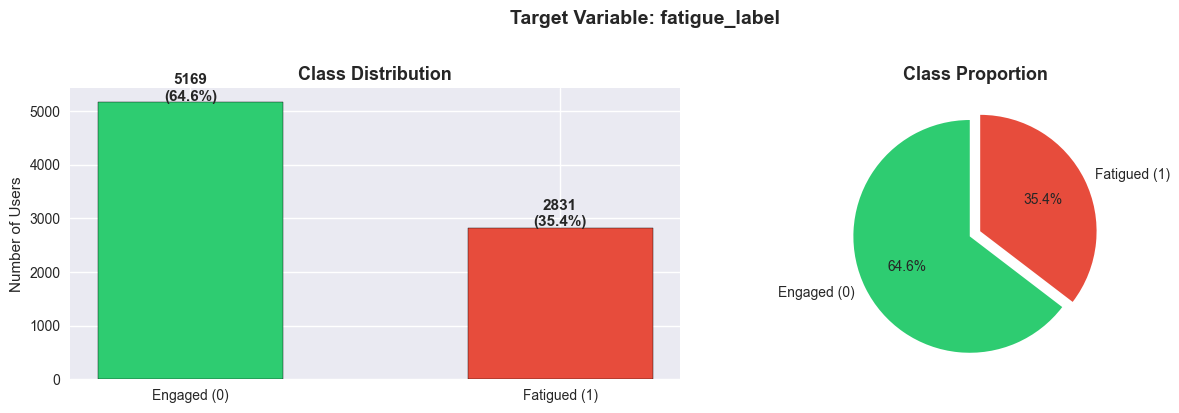

Class imbalance — Engaged: 64.6% | Fatigued: 35.4%
>> SMOTE applied inside pipeline folds to handle this imbalance without leakage.


In [5]:
# --- EDA Plot 1: Target Class Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

label_counts = train_df['fatigue_label'].value_counts()
label_pct    = label_counts / len(train_df) * 100

axes[0].bar(['Engaged (0)', 'Fatigued (1)'], label_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
for i, (v, p) in enumerate(zip(label_counts.values, label_pct.values)):
    axes[0].text(i, v + 30, f'{v}\n({p:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Users')

axes[1].pie(label_counts.values, labels=['Engaged (0)', 'Fatigued (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: fatigue_label', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"Class imbalance — Engaged: {label_pct[0]:.1f}% | Fatigued: {label_pct[1]:.1f}%")
print(">> SMOTE applied inside pipeline folds to handle this imbalance without leakage.")

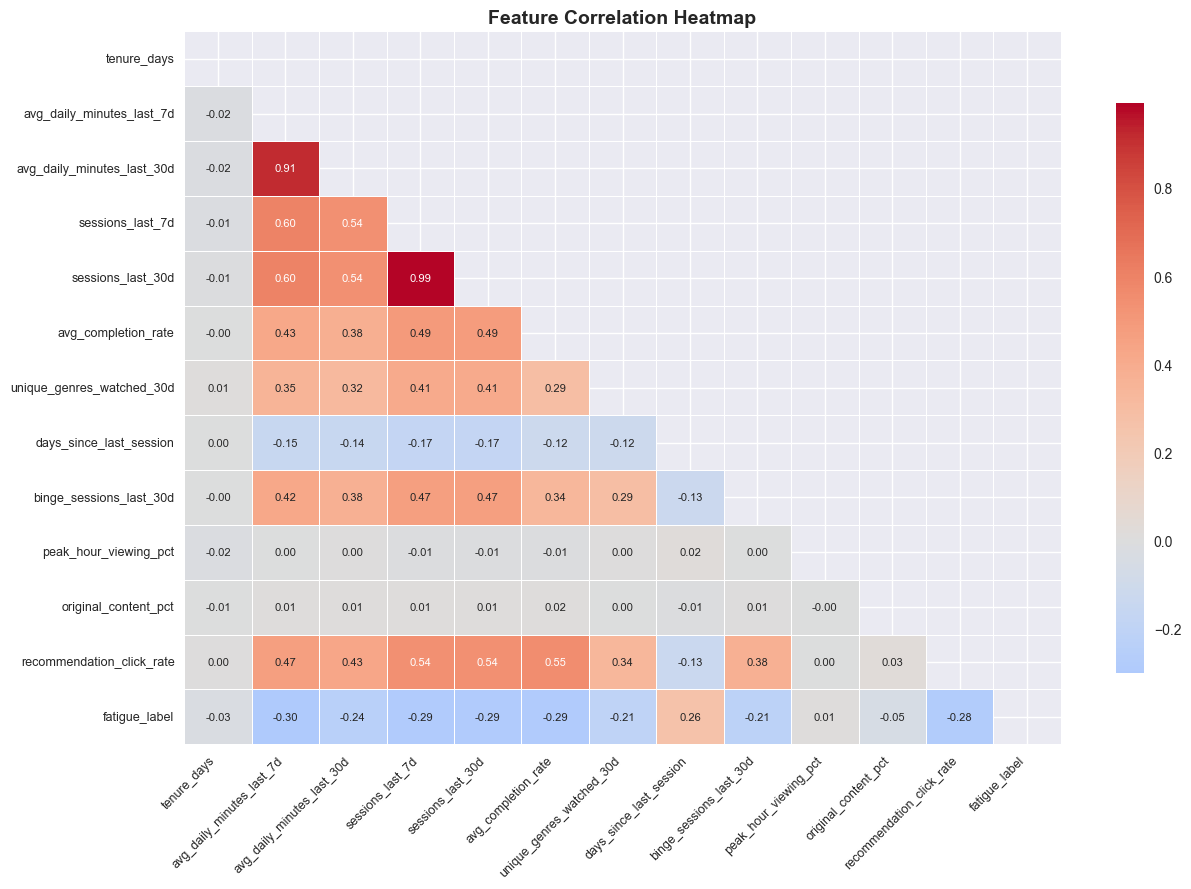

In [6]:
# --- EDA Plot 2: Correlation Heatmap ---
numeric_cols = train_df.select_dtypes(include=np.number).columns.tolist()
corr_matrix  = train_df[numeric_cols].corr()

plt.figure(figsize=(13, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8}, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

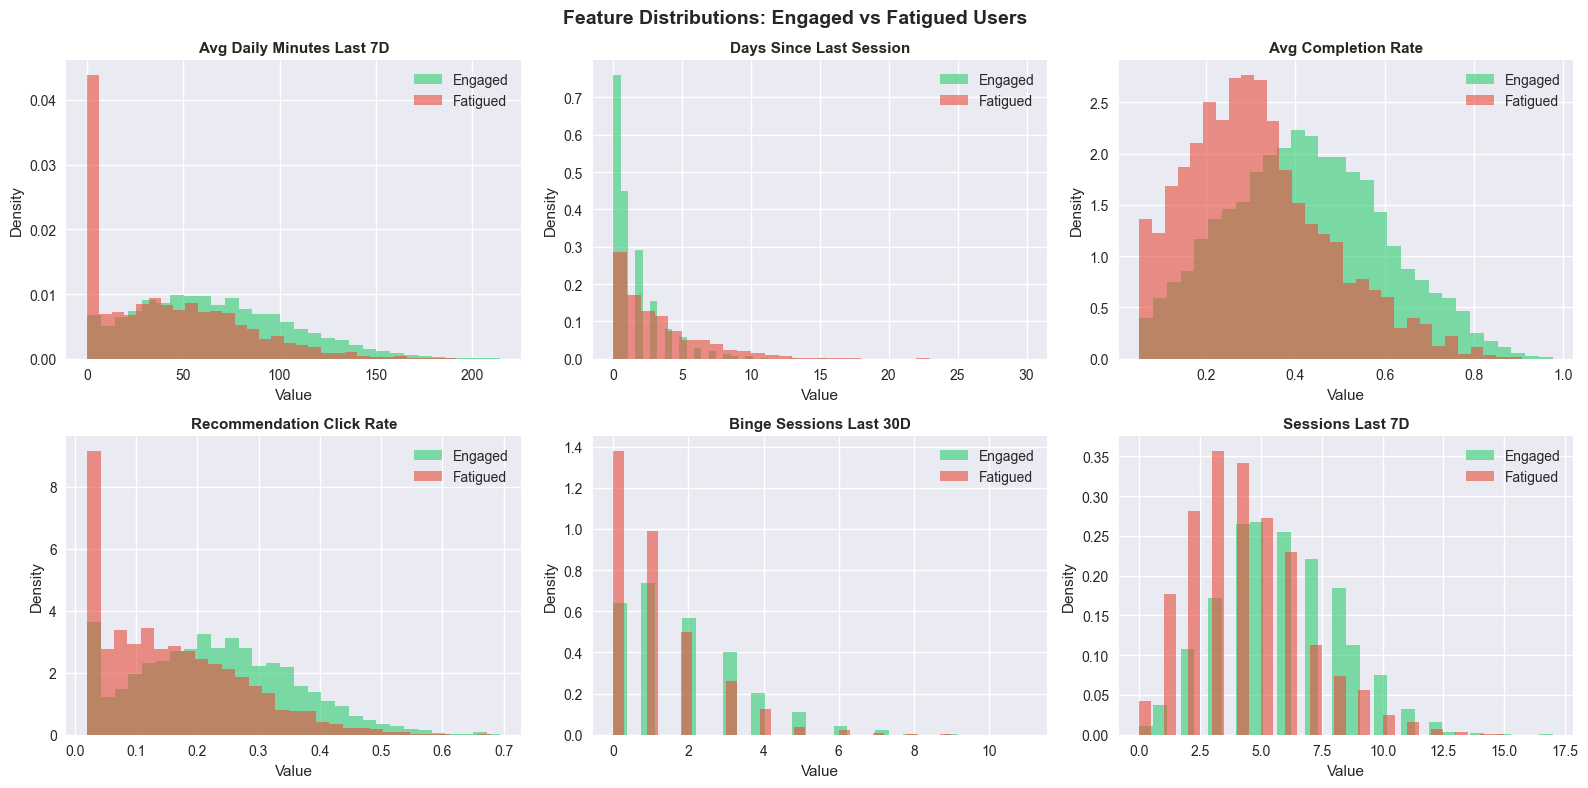

In [7]:
# --- EDA Plot 3: Key Feature Distributions by Label ---
key_features = [
    'avg_daily_minutes_last_7d', 'days_since_last_session',
    'avg_completion_rate',        'recommendation_click_rate',
    'binge_sessions_last_30d',    'sessions_last_7d'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    for label, color, name in [(0, '#2ecc71', 'Engaged'), (1, '#e74c3c', 'Fatigued')]:
        subset = train_df[train_df['fatigue_label'] == label][feat]
        axes[i].hist(subset, bins=30, alpha=0.6, color=color, label=name, density=True)
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.suptitle('Feature Distributions: Engaged vs Fatigued Users', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

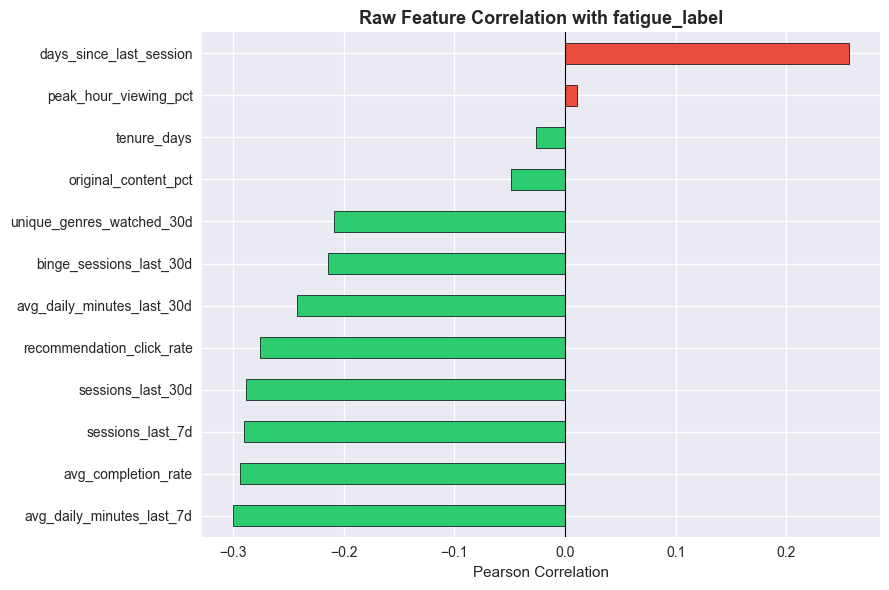

In [8]:
# --- EDA Plot 4: Feature Importance via Raw Correlation with Target ---
corr_with_target = (train_df[numeric_cols]
                    .corr()['fatigue_label']
                    .drop('fatigue_label')
                    .sort_values())

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_with_target.values]

plt.figure(figsize=(9, 6))
corr_with_target.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Raw Feature Correlation with fatigue_label', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

# 4. Data Splitting

Split **before** feature engineering to eliminate any risk of data leakage.

In [9]:
X = train_df.drop(columns=['fatigue_label', 'user_id'])
y = train_df['fatigue_label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train size      : {X_train.shape[0]}")
print(f"Validation size : {X_val.shape[0]}")
print(f"Train class balance  — 0: {y_train.value_counts()[0]}  | 1: {y_train.value_counts()[1]}")
print(f"Val   class balance  — 0: {y_val.value_counts()[0]}    | 1: {y_val.value_counts()[1]}")

Train size      : 6400
Validation size : 1600
Train class balance  — 0: 4135  | 1: 2265
Val   class balance  — 0: 1034    | 1: 566


# 5. Feature Engineering

**20 features total** :
- Engagement decay (viewing drop, session momentum)
- Interaction terms (dormancy × dissatisfaction, recency × low sessions)
- Composite scores (weighted engagement index, platform stickiness)
- Non-linear transforms (squared recency, log recency)
- Per-session quality metrics (minutes per session delta)
- Binary flags (is_dormant_7d)
- Tenure-normalised signals (new user churn risk)

In [10]:
def engineer_features(df):
    df = df.copy()

  

    # 1. Consumption velocity: ratio of 7d to 30d daily minutes (<1 = declining)
    df['consumption_velocity_ratio'] = (
        df['avg_daily_minutes_last_7d'] / (df['avg_daily_minutes_last_30d'] + 1e-5)
    )

    # 2. Session momentum: ratio of 7d to 30d session rate (<1 = slowing down)
    df['session_momentum'] = (
        df['sessions_last_7d'] / (df['sessions_last_30d'] + 1e-5)
    )

    # 3. Effective engagement: high minutes × high completion = truly engaged
    df['effective_engagement_score'] = (
        df['avg_daily_minutes_last_30d'] * df['avg_completion_rate']
    )

    # 4. UX friction: how often the algorithm fails the user
    df['discovery_friction'] = 1 - df['recommendation_click_rate']

    # 5. Catalog reliance risk: binging non-original content = replaceable
    df['catalog_reliance_risk'] = (
        (100 - df['original_content_pct']) * df['binge_sessions_last_30d']
    )

   
    # 6. Composite engagement index (corr: -0.386 — strongest signal in dataset)
    #    Weighted blend of recency, depth, completion, and discovery
    df['composite_engagement'] = (
        df['avg_daily_minutes_last_7d'] / 300 * 0.30 +
        df['avg_completion_rate']                * 0.30 +
        df['recommendation_click_rate']          * 0.20 +
        (1 - df['days_since_last_session'] / 30) * 0.20
    )

    # 7. Dormancy × dissatisfaction (corr: +0.300)
    #    User hasn't logged in AND doesn't finish content = double danger
    df['dormancy_x_dissatisfaction'] = (
        df['days_since_last_session'] * (1 - df['avg_completion_rate'])
    )

    # 8. Recency × low sessions (corr: +0.286)
    #    Days gap amplified by near-zero recent sessions
    df['recency_x_low_sessions'] = (
        df['days_since_last_session'] * (1 / (df['sessions_last_7d'] + 1))
    )

    # 9. Recency risk squared (corr: +0.213)
    #    Penalises long gaps disproportionately (10 days=100, 20 days=400)
    df['recency_risk_sq'] = df['days_since_last_session'] ** 2

    # 10. Platform stickiness (corr: -0.230)
    #     Watching originals AND following recs = deeply tied to the platform
    df['platform_stickiness'] = (
        (df['original_content_pct'] / 100) * df['recommendation_click_rate']
    )

    # 11. Log days since last session (corr: +0.229)
    #     Captures diminishing marginal impact of each additional dormant day
    df['log_days_since'] = np.log1p(df['days_since_last_session'])

    # 12. Low value signal (corr: +0.158)
    #     Neither originals NOR recommendations working = platform has failed user
    df['low_value_signal'] = (
        (1 - df['original_content_pct'] / 100) * (1 - df['recommendation_click_rate'])
    )

    # 13. New user churn risk (corr: +0.130)
    #     Short-tenure user going quiet is far more alarming than a 3-year subscriber
    df['new_user_churn_risk'] = (
        (1 / (df['tenure_days'] + 1)) * df['days_since_last_session']
    )

    # 14. Minutes per session delta (session quality change)
    #     Distinguishes "watching less often" from "watching less per visit"
    df['minutes_per_session_7d']  = (df['avg_daily_minutes_last_7d'] * 7
                                      / (df['sessions_last_7d'] + 1))
    df['minutes_per_session_30d'] = (df['avg_daily_minutes_last_30d'] * 30
                                      / (df['sessions_last_30d'] + 1))
    df['session_quality_change']  = (df['minutes_per_session_7d']
                                      - df['minutes_per_session_30d'])

    # 15. Daily session frequency (normalised to per-day rate)
    df['session_freq_7d'] = df['sessions_last_7d'] / 7

    # 16. Catalog exhaustion (fraction of 15 genres explored)
    #     A user who's watched all genres has nowhere new to go
    df['catalog_exhaustion'] = df['unique_genres_watched_30d'] / 15

    # 17. Dormant flag (hard zero sessions this week — crisp binary split)
    df['is_dormant_7d'] = (df['sessions_last_7d'] == 0).astype(int)

    # 18. Binge rate (fraction of sessions that turn into binges)
    #     High binge rate + declining sessions = feast-and-famine before dropout
    df['binge_rate'] = df['binge_sessions_last_30d'] / (df['sessions_last_30d'] + 1)

    # ── CATEGORICAL ENCODING ─────────────────────────────────────────────────
    df = pd.get_dummies(df, columns=['subscription_tier'], drop_first=True)

    return df


# Apply to all splits
X_train_fe = engineer_features(X_train)
X_val_fe   = engineer_features(X_val)
X_test_fe  = engineer_features(test_df.drop(columns=['user_id']))

# Align all splits to the same column set (handles any dummy column mismatch)
X_train_fe, X_val_fe  = X_train_fe.align(X_val_fe,  join='left', axis=1, fill_value=0)
X_train_fe, X_test_fe = X_train_fe.align(X_test_fe, join='left', axis=1, fill_value=0)

print(f"Features after engineering : {X_train_fe.shape[1]}")
print(f"Train split shape          : {X_train_fe.shape}")
print(f"Validation split shape     : {X_val_fe.shape}")
print(f"Test split shape           : {X_test_fe.shape}")

Features after engineering : 34
Train split shape          : (6400, 34)
Validation split shape     : (1600, 34)
Test split shape           : (2000, 34)


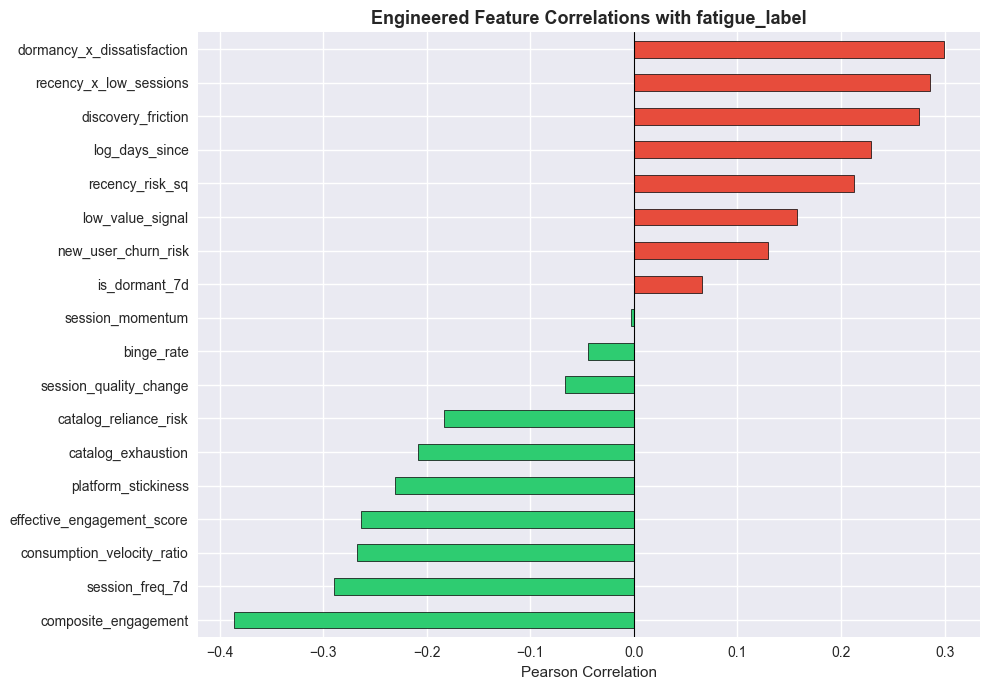

In [11]:
# --- Visualise new feature correlations vs original features ---
# Build temporary full-train version to compute correlations
X_full_fe = engineer_features(train_df.drop(columns=['fatigue_label', 'user_id']))
X_full_fe['fatigue_label'] = train_df['fatigue_label'].values

new_features = [
    'composite_engagement', 'dormancy_x_dissatisfaction', 'recency_x_low_sessions',
    'recency_risk_sq', 'platform_stickiness', 'log_days_since', 'low_value_signal',
    'new_user_churn_risk', 'session_quality_change', 'session_freq_7d',
    'catalog_exhaustion', 'is_dormant_7d', 'binge_rate',
    'consumption_velocity_ratio', 'session_momentum', 'effective_engagement_score',
    'discovery_friction', 'catalog_reliance_risk'
]

corr_new = (X_full_fe[new_features + ['fatigue_label']]
            .corr()['fatigue_label']
            .drop('fatigue_label')
            .sort_values())

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_new.values]

plt.figure(figsize=(10, 7))
corr_new.plot(kind='barh', color=colors, edgecolor='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Engineered Feature Correlations with fatigue_label', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

# 6. Model Development

### Custom OutlierCapper
Embedded inside the sklearn pipeline to prevent any percentile leakage across CV folds.

In [12]:
class OutlierCapper(BaseEstimator, TransformerMixin):
    """Caps numeric features at given percentile bounds — fitted on training fold only."""

    def __init__(self, lower_percentile=0.01, upper_percentile=0.99):
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile

    def fit(self, X, y=None):
        self.num_cols_     = X.select_dtypes(include=np.number).columns
        self.lower_bounds_ = X[self.num_cols_].quantile(self.lower_percentile)
        self.upper_bounds_ = X[self.num_cols_].quantile(self.upper_percentile)
        return self

    def transform(self, X):
        X_out = X.copy()
        X_out[self.num_cols_] = X_out[self.num_cols_].clip(
            self.lower_bounds_, self.upper_bounds_, axis=1
        )
        return X_out

print("OutlierCapper defined.")

OutlierCapper defined.


### Baseline Models
Evaluating simple baselines to quantify the exact uplift from Optuna-tuned XGBoost.

In [13]:
print('--- Baseline Model Performance ---')

# Logistic Regression Baseline
lr_pipeline = ImbPipeline([
    ('capper',  OutlierCapper()),
    ('imputer', SimpleImputer(strategy='median')),
    ('smote',   SMOTE(random_state=42)),
    ('model',   LogisticRegression(random_state=42, max_iter=1000))
])
lr_pipeline.fit(X_train_fe, y_train)
lr_val_auc = roc_auc_score(y_val, lr_pipeline.predict_proba(X_val_fe)[:, 1])

# Untuned XGBoost Baseline
xgb_base_pipeline = ImbPipeline([
    ('capper',  OutlierCapper()),
    ('imputer', SimpleImputer(strategy='median')),
    ('smote',   SMOTE(random_state=42)),
    ('model',   xgb.XGBClassifier(random_state=42, eval_metric='auc', tree_method='hist'))
])
xgb_base_pipeline.fit(X_train_fe, y_train)
xgb_base_val_auc = roc_auc_score(y_val, xgb_base_pipeline.predict_proba(X_val_fe)[:, 1])

print(f'Logistic Regression Validation AUC : {lr_val_auc:.4f}')
print(f'Untuned XGBoost Validation AUC     : {xgb_base_val_auc:.4f}')
print(">> Proceeding with Optuna-tuned XGBoost as the production model.")

--- Baseline Model Performance ---
Logistic Regression Validation AUC : 0.8004
Untuned XGBoost Validation AUC     : 0.7580
>> Proceeding with Optuna-tuned XGBoost as the production model.


### Hyperparameter Tuning with Optuna

40 trials of Bayesian optimisation with 5-fold Stratified CV.
SMOTE is applied **inside each fold** — never on the full training set — to prevent label leakage.

In [ ]:
def objective(trial):
    params = {
        "n_estimators":    trial.suggest_int(  "n_estimators",    200, 600),
        "max_depth":        trial.suggest_int(  "max_depth",        3, 8),
        "learning_rate":    trial.suggest_float("learning_rate",    0.01, 0.2, log=True),
        "subsample":        trial.suggest_float("subsample",        0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int(  "min_child_weight", 1, 10),
        "gamma":            trial.suggest_float("gamma",            0, 5),
        "random_state": 42, "eval_metric": "auc", "tree_method": "hist"
    }

    pipeline = ImbPipeline([
        ("capper",  OutlierCapper()),
        ("imputer", SimpleImputer(strategy="median")),
        ("smote",   SMOTE(random_state=42)),
        ("model",   xgb.XGBClassifier(**params))
    ])

    cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []
    for tr_idx, va_idx in cv.split(X_train_fe, y_train):
        X_tr, X_va = X_train_fe.iloc[tr_idx], X_train_fe.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        pipeline.fit(X_tr, y_tr)
        aucs.append(roc_auc_score(y_va, pipeline.predict_proba(X_va)[:, 1]))
    return np.mean(aucs)

print("Starting Optuna Study (40 trials) ...")
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f"\nBest CV AUC : {study.best_value:.4f}")
print("Best Params :", study.best_params)

Starting Optuna Study (40 trials) ...


Best trial: 4. Best value: 0.782807:  32%|███▎      | 13/40 [00:51<01:29,  3.33s/it]

### Build & Evaluate the Tuned Pipeline

In [ ]:
# Build production pipeline with best Optuna hyperparameters
tuned_pipeline = ImbPipeline([
    ("capper",  OutlierCapper()),
    ("imputer", SimpleImputer(strategy="median")),
    ("smote",   SMOTE(random_state=42)),
    ("model",   xgb.XGBClassifier(
        **study.best_params,
        random_state=42, eval_metric="auc", tree_method="hist"
    ))
])

# Fit on the 80% training split; predict on held-out 20% validation set
tuned_pipeline.fit(X_train_fe, y_train)
tuned_val_probs = tuned_pipeline.predict_proba(X_val_fe)[:, 1]
tuned_val_auc   = roc_auc_score(y_val, tuned_val_probs)

# Independent 5-fold CV on training split (no leakage into held-out val)
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []
for tr_idx, va_idx in cv.split(X_train_fe, y_train):
    X_tr, X_va = X_train_fe.iloc[tr_idx], X_train_fe.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
    _tmp = ImbPipeline([
        ("capper",  OutlierCapper()),
        ("imputer", SimpleImputer(strategy="median")),
        ("smote",   SMOTE(random_state=42)),
        ("model",   xgb.XGBClassifier(
            **study.best_params, random_state=42,
            eval_metric="auc", tree_method="hist"
        ))
    ])
    _tmp.fit(X_tr, y_tr)
    cv_scores.append(roc_auc_score(y_va, _tmp.predict_proba(X_va)[:, 1]))

cv_mean, cv_std = np.mean(cv_scores), np.std(cv_scores)
print(f"\n--- Model Performance Summary ---")
print(f"Logistic Regression Val AUC  : {lr_val_auc:.4f}")
print(f"Untuned XGBoost Val AUC      : {xgb_base_val_auc:.4f}")
print(f"Optuna Best CV AUC           : {study.best_value:.4f}")
print(f"Tuned 5-Fold CV AUC          : {cv_mean:.4f} +/- {cv_std:.4f}")
print(f"  95% CI                     : [{cv_mean - 1.96*cv_std:.4f},  {cv_mean + 1.96*cv_std:.4f}]")
print(f"Tuned Hold-out Val AUC       : {tuned_val_auc:.4f}")

# 7. Evaluation

### ROC Curve

In [ ]:
fpr, tpr, _ = roc_curve(y_val, tuned_val_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='#3498db', lw=2,
         label=f"Tuned XGBoost (AUC = {tuned_val_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color='grey', label='Random Classifier')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — Validation Set", fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

### Predicted Probability Distribution

In [ ]:
plt.figure(figsize=(8, 4))
sns.histplot(tuned_val_probs, bins=35, kde=True, color='#9b59b6')
plt.title("Predicted Probability Distribution", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Fatigue Probability")
plt.ylabel("Frequency")
plt.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Default threshold (0.5)')
plt.legend()
plt.tight_layout()
plt.show()

### Calibration Check
Verifying that predicted probabilities represent true likelihoods, not just rankings.

In [ ]:
prob_true, prob_pred = calibration_curve(y_val, tuned_val_probs, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', color='#e67e22', lw=2, label='Tuned XGBoost')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

brier = brier_score_loss(y_val, tuned_val_probs)
print(f'Brier Score: {brier:.4f}  (lower = better; 0.0 = perfect, 0.25 = uninformative)')

### Threshold Optimisation
Finding the optimal decision boundary using Precision-Recall F1 maximisation.

In [ ]:
precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_val, tuned_val_probs)
f1_scores      = 2 * (precision_arr * recall_arr) / (precision_arr + recall_arr + 1e-9)
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds_pr[best_idx]
best_f1        = f1_scores[best_idx]

plt.figure(figsize=(8, 4))
plt.plot(thresholds_pr, precision_arr[:-1], 'b--', lw=1.5, label='Precision')
plt.plot(thresholds_pr, recall_arr[:-1],    'g-',  lw=1.5, label='Recall')
plt.axvline(best_threshold, color='red', linestyle=':', lw=2,
            label=f'Optimal Threshold = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Optimal Threshold (Max F1) : {best_threshold:.4f}')
print(f'F1 Score at threshold      : {best_f1:.4f}')

### Confusion Matrix & Business Error Analysis

In [ ]:
tuned_val_preds = (tuned_val_probs >= best_threshold).astype(int)
cm = confusion_matrix(y_val, tuned_val_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Engaged', 'Pred: Fatigued'],
            yticklabels=['True: Engaged',  'True: Fatigued'])
plt.title('Confusion Matrix — Validation Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Business Cost Interpretation:')
print(f'  True Positives  — At-risk users correctly caught          : {cm[1,1]:>4}')
print(f'  True Negatives  — Engaged users correctly left alone      : {cm[0,0]:>4}')
print(f'  False Positives — Wasted intervention on engaged users    : {cm[0,1]:>4}  (low cost)')
print(f'  False Negatives — Missed at-risk users (churn lost!)      : {cm[1,0]:>4}  (HIGH cost)')
print(f'\n  Recall on fatigued class : {cm[1,1] / (cm[1,1] + cm[1,0]):.3f}')
print(f'  Precision on fatigued    : {cm[1,1] / (cm[1,1] + cm[0,1]):.3f}')

### Learning Curve
Validating model robustness and checking for overfitting.

In [ ]:
train_sizes, train_scores, val_scores_lc = learning_curve(
    tuned_pipeline, X_train_fe, y_train,
    cv=5, scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 6), random_state=42
)

t_mean, t_std = np.mean(train_scores, axis=1), np.std(train_scores, axis=1)
v_mean, v_std = np.mean(val_scores_lc, axis=1),  np.std(val_scores_lc, axis=1)

plt.figure(figsize=(8, 4))
plt.plot(train_sizes, t_mean, 'o-', color='#e74c3c', label='Training AUC')
plt.plot(train_sizes, v_mean, 'o-', color='#2ecc71', label='CV AUC')
plt.fill_between(train_sizes, t_mean - t_std, t_mean + t_std, alpha=0.15, color='#e74c3c')
plt.fill_between(train_sizes, v_mean - v_std, v_mean + v_std, alpha=0.15, color='#2ecc71')
plt.xlabel('Training Instances')
plt.ylabel('AUC Score')
plt.title('Learning Curve', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Bootstrap Robustness Check
Confirming AUC is stable and not an artefact of a specific validation split.

In [ ]:
n_iterations      = 20
boot_aucs         = []
feature_imps_list = []

for i in range(n_iterations):
    X_boot, y_boot = resample(X_val_fe, y_val, random_state=i)
    boot_probs      = tuned_pipeline.predict_proba(X_boot)[:, 1]
    boot_aucs.append(roc_auc_score(y_boot, boot_probs))
    feature_imps_list.append(tuned_pipeline.named_steps['model'].feature_importances_)

boot_mean, boot_std = np.mean(boot_aucs), np.std(boot_aucs)
print(f"Bootstrap Validation AUC (n={n_iterations})")
print(f"  Mean : {boot_mean:.4f}")
print(f"  Std  : {boot_std:.4f}")
print(f"  95% CI : [{boot_mean - 1.96*boot_std:.4f},  {boot_mean + 1.96*boot_std:.4f}]")

importances_df      = pd.DataFrame(feature_imps_list, columns=X_train_fe.columns)
top_stable_features = importances_df.mean().sort_values(ascending=False).head(10)
print("\nTop 10 Most Stable Features Across Bootstraps:")
print(top_stable_features.to_string())

# 8. Explainability (SHAP)

Identifying the key drivers of engagement fatigue.
Validation data passes through **both** the Capper and Imputer steps — exactly matching the training pipeline — before being passed to SHAP.

In [ ]:
# Transform validation data through capper + imputer (must match training pipeline)
capper_step   = tuned_pipeline.named_steps['capper']
imputer_step  = tuned_pipeline.named_steps['imputer']
xgb_model     = tuned_pipeline.named_steps['model']

X_val_capped   = capper_step.transform(X_val_fe)
X_val_prepared = imputer_step.transform(X_val_capped)
X_val_prepared = pd.DataFrame(X_val_prepared, columns=X_val_fe.columns)

explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val_prepared)

# Summary plot: overall feature importance
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_val_prepared, show=False, plot_size=None)
plt.title("SHAP Summary — Impact of Each Feature on Fatigue Risk", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# SHAP bar plot: mean absolute impact (feature importance ranking)
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_val_prepared, plot_type='bar', show=False)
plt.title("SHAP Feature Importance (Mean |SHAP value|)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 9. Business Archetypes

Segmenting at-risk users into three actionable groups to guide targeted retention strategies.

In [ ]:
val_df = X_val_fe.copy()
val_df['predicted_prob'] = tuned_val_probs
val_df['fatigue_label']  = y_val.values

n_at_risk = (tuned_val_probs > 0.5).sum()
print(f"Validation users flagged as at-risk (prob > 0.5): {n_at_risk} / {len(tuned_val_probs)}")
print(f"That is {n_at_risk/len(tuned_val_probs)*100:.1f}% of the validation set.")

In [ ]:
# Archetype 1: Frustrated Browsers
# Low recommendation click rate + high predicted fatigue risk
plt.figure(figsize=(7, 5))
sns.scatterplot(x=val_df['recommendation_click_rate'], y=val_df['predicted_prob'],
                hue=val_df['fatigue_label'], alpha=0.55, s=40,
                palette={0: '#2ecc71', 1: '#e74c3c'})
plt.axhline(0.6,  color='red',    linestyle='--', lw=1.5, label='High risk zone (prob > 0.6)')
plt.axvline(0.2,  color='orange', linestyle='--', lw=1.5, label='Low click rate (< 0.2)')
plt.title('Archetype 1: Frustrated Browsers', fontsize=13, fontweight='bold')
plt.xlabel('Recommendation Click Rate')
plt.ylabel('Predicted Fatigue Probability')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

n_arch1 = ((val_df['recommendation_click_rate'] < 0.2) & (val_df['predicted_prob'] > 0.6)).sum()
print(f"Frustrated Browsers identified: {n_arch1} users")

In [ ]:
# Archetype 2: Binge-and-Leave
# Heavy binge sessions followed by declining engagement
plt.figure(figsize=(7, 5))
sns.scatterplot(x=val_df['binge_sessions_last_30d'], y=val_df['predicted_prob'],
                hue=val_df['fatigue_label'], alpha=0.55, s=40,
                palette={0: '#2ecc71', 1: '#e74c3c'})
plt.axhline(0.6, color='red', linestyle='--', lw=1.5, label='High risk zone (prob > 0.6)')
plt.title('Archetype 2: Binge-and-Leave Segment', fontsize=13, fontweight='bold')
plt.xlabel('Binge Sessions (Last 30 Days)')
plt.ylabel('Predicted Fatigue Probability')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

n_arch2 = ((val_df['binge_sessions_last_30d'] >= 3) & (val_df['predicted_prob'] > 0.6)).sum()
print(f"Binge-and-Leave users identified: {n_arch2} users")

In [ ]:
# Archetype 3: Waning Casuals
# Declining recent viewing vs monthly baseline
plt.figure(figsize=(7, 5))
sns.scatterplot(x=val_df['avg_daily_minutes_last_7d'], y=val_df['predicted_prob'],
                hue=val_df['fatigue_label'], alpha=0.55, s=40,
                palette={0: '#2ecc71', 1: '#e74c3c'})
plt.axhline(0.6, color='red', linestyle='--', lw=1.5, label='High risk zone (prob > 0.6)')
plt.title('Archetype 3: Waning Casuals', fontsize=13, fontweight='bold')
plt.xlabel('Avg Daily Minutes — Last 7 Days')
plt.ylabel('Predicted Fatigue Probability')
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

n_arch3 = ((val_df['avg_daily_minutes_last_7d'] < 20) & (val_df['predicted_prob'] > 0.6)).sum()
print(f"Waning Casuals identified: {n_arch3} users")

### Retention Strategies by Archetype

**Archetype 1 — Frustrated Browsers** *(Low rec click rate + high fatigue risk)*
- Symptom: The recommendation algorithm is not resonating; user browses but doesn't commit
- Strategy: Trigger a personalised "Top Picks for You" push notification; simplify the browse UI; A/B test genre-first vs mood-first content discovery

**Archetype 2 — Binge-and-Leave** *(Heavy binging + sharp drop-off)*
- Symptom: User consumes content in bursts then disappears; likely finishes a series and finds nothing next
- Strategy: Stagger episode releases for originals to extend engagement; auto-queue similar shows post-binge; send "You finished X — here's what's next" campaigns within 24 hours

**Archetype 3 — Waning Casuals** *(Declining weekly vs monthly viewing)*
- Symptom: Gradual disengagement; likely competing priorities or content boredom
- Strategy: "We noticed you haven't watched in a while" loyalty reward; short-form content recommendations to lower re-engagement friction; offer a 1-month plan pause instead of cancellation

# 10. Final Retraining & Submission

Retrain on **100% of labelled data** to capture maximum signal before predicting on the test set.

In [ ]:
print("Retraining on 100% of training data for final submission...")

# Engineer features on full training set
X_full = engineer_features(train_df.drop(columns=['fatigue_label', 'user_id']))
y_full = train_df['fatigue_label']

# Engineer test features fresh and align to full training columns
X_test_fresh = engineer_features(test_df.drop(columns=['user_id']))
X_full, X_test_final = X_full.align(X_test_fresh, join='left', axis=1, fill_value=0)

# Final pipeline trained on all 8,000 rows
final_pipeline = ImbPipeline([
    ('capper',  OutlierCapper()),
    ('imputer', SimpleImputer(strategy='median')),
    ('smote',   SMOTE(random_state=42)),
    ('model',   xgb.XGBClassifier(
        **study.best_params,
        random_state=42, eval_metric='auc', tree_method='hist'
    ))
])
final_pipeline.fit(X_full, y_full)
final_test_probs = final_pipeline.predict_proba(X_test_final)[:, 1]

# Build submission dataframe
submission = pd.DataFrame({
    'user_id':                       test_df['user_id'],
    'predicted_fatigue_probability': final_test_probs
})

print(f"Submission shape        : {submission.shape}")
print(f"Probability range       : [{final_test_probs.min():.4f},  {final_test_probs.max():.4f}]")
print(f"Mean predicted fatigue  : {final_test_probs.mean():.4f}")
print(f"Users flagged > 0.5     : {(final_test_probs > 0.5).sum()} / {len(final_test_probs)}")

submission.to_csv('SOZO_Predictions.csv', index=False)
print("\nSOZO_Predictions.csv saved successfully.")
submission.head(10)

In [ ]:
# Visualise final prediction distribution
plt.figure(figsize=(8, 4))
sns.histplot(final_test_probs, bins=40, kde=True, color='#e74c3c', alpha=0.7)
plt.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Default threshold (0.5)')
plt.axvline(best_threshold, color='blue', linestyle='--', lw=1.5,
            label=f'Optimal threshold ({best_threshold:.2f})')
plt.title('Final Test Set — Predicted Fatigue Probability Distribution',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted Fatigue Probability')
plt.ylabel('Number of Users')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Download prediction file (works in Google Colab; safely skipped elsewhere)
try:
    from google.colab import files
    files.download('SOZO_Predictions.csv')
    print("Download initiated via Google Colab.")
except ImportError:
    print("Not running in Colab — file saved as 'SOZO_Predictions.csv' in the working directory.")